In [52]:
import importlib
import linear_model

importlib.reload(linear_model)
from linear_model import softmax

In [53]:
import linear_model
print(dir(linear_model))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'accuracy', 'compute_gradients', 'compute_scores', 'cross_entropy_loss', 'initialize_parameters', 'np', 'predict', 'softmax', 'train_linear_model', 'update_parameters']


## References :
- (initialisation aleatoire des poids) https://cs231n.github.io/neural-networks-2/
- (scikitlearn) (eviter les erreurs numeriques du type ln(0)) : https://scikit-learn.org/stable/modules/generated/sklearn.metrics.log_loss.html?utm_source=chatgpt.com
- (derivee de softmax) : https://mldawn.com/the-derivative-of-softmaxz-function-w-r-t-z/

# 1) Import de MNIST

=== Dimensions initiales ===
X_train : (60000, 28, 28)
y_train : (60000,)
X_test  : (10000, 28, 28)
y_test  : (10000,)

=== Type des données ===
X_train dtype : uint8
X_test dtype  : uint8
y_train dtype : uint8
y_test dtype  : uint8

=== Labels présents ===
Classes dans y_train : [0 1 2 3 4 5 6 7 8 9]
Classes dans y_test  : [0 1 2 3 4 5 6 7 8 9]

Toutes les vérifications globales sont OK.


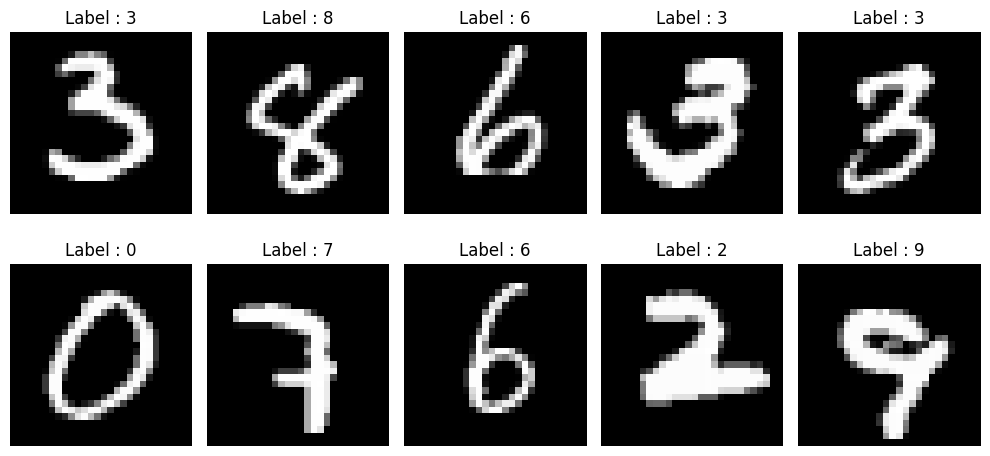


=== Valeurs des pixels avant normalisation ===
Min train : 0 | Max train : 255
Min test  : 0 | Max test  : 255

=== Valeurs des pixels après normalisation ===
Min train : 0.0 | Max train : 1.0
Min test  : 0.0 | Max test  : 1.0

=== Dimensions après aplatissement ===
X_train_flat : (60000, 784)
X_test_flat  : (10000, 784)

Préparation des données terminée avec succès.


In [54]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# =========================
# 1) Chargement du dataset
# =========================
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# =========================
# 2) Vérifications globales
# =========================
print("=== Dimensions initiales ===")
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)
print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)

print("\n=== Type des données ===")
print("X_train dtype :", X_train.dtype)
print("X_test dtype  :", X_test.dtype)
print("y_train dtype :", y_train.dtype)
print("y_test dtype  :", y_test.dtype)

print("\n=== Labels présents ===")
print("Classes dans y_train :", np.unique(y_train))
print("Classes dans y_test  :", np.unique(y_test))

# Vérifie que chaque image est bien de taille 28x28
assert X_train.ndim == 3, "X_train ne contient pas des images 2D."
assert X_test.ndim == 3, "X_test ne contient pas des images 2D."
assert X_train.shape[1:] == (28, 28), "Certaines images de train ne sont pas en 28x28."
assert X_test.shape[1:] == (28, 28), "Certaines images de test ne sont pas en 28x28."

# Vérifie qu'il n'y a pas de NaN ou d'inf
assert not np.isnan(X_train).any(), "NaN détecté dans X_train."
assert not np.isnan(X_test).any(), "NaN détecté dans X_test."
assert not np.isinf(X_train).any(), "Inf détecté dans X_train."
assert not np.isinf(X_test).any(), "Inf détecté dans X_test."

print("\nToutes les vérifications globales sont OK.")

# =========================
# 3) Affichage de quelques images brutes
# =========================
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
indices = np.random.choice(len(X_train), 10, replace=False)

for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_train[idx], cmap="gray")
    ax.set_title(f"Label : {y_train[idx]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# =========================
# 4) Vérification des intensités de pixels
# =========================
print("\n=== Valeurs des pixels avant normalisation ===")
print("Min train :", X_train.min(), "| Max train :", X_train.max())
print("Min test  :", X_test.min(), "| Max test  :", X_test.max())

# =========================
# 5) Conversion en float + normalisation
# =========================
X_train = X_train.astype(np.float64) / 255.0
X_test = X_test.astype(np.float64) / 255.0

print("\n=== Valeurs des pixels après normalisation ===")
print("Min train :", X_train.min(), "| Max train :", X_train.max())
print("Min test  :", X_test.min(), "| Max test  :", X_test.max())

# =========================
# 6) Aplatissement 28x28 -> 784
# =========================
X_train_flat = X_train.reshape(X_train.shape[0], 28 * 28)
X_test_flat = X_test.reshape(X_test.shape[0], 28 * 28)

print("\n=== Dimensions après aplatissement ===")
print("X_train_flat :", X_train_flat.shape)
print("X_test_flat  :", X_test_flat.shape)

# Vérification finale
assert X_train_flat.shape[1] == 784, "Les images train n'ont pas été aplaties correctement."
assert X_test_flat.shape[1] == 784, "Les images test n'ont pas été aplaties correctement."

print("\nPréparation des données terminée avec succès.")


# One-Hot encoding

In [55]:
import numpy as np

## Import de la fonction d'encodage des labels
from utils import one_hot_encode

# Encodage des labels
Y_train = one_hot_encode(y_train, num_classes=10)
Y_test = one_hot_encode(y_test, num_classes=10)

# Vérifications
print("y_train shape :", y_train.shape)
print("Y_train shape :", Y_train.shape)

print("\nExemples :")
for i in range(5):
    print(f"label brut = {y_train[i]}  ->  one-hot = {Y_train[i]}")

y_train shape : (60000,)
Y_train shape : (60000, 10)

Exemples :
label brut = 5  ->  one-hot = [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
label brut = 0  ->  one-hot = [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
label brut = 4  ->  one-hot = [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
label brut = 1  ->  one-hot = [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
label brut = 9  ->  one-hot = [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


# Softmax

fonction softmax

In [56]:
from linear_model import softmax

# Test
scores_test = np.array([[1.0, 2.0, 3.0],
                        [0.5, 0.1, -1.2]])

probs_test = softmax(scores_test)

print("Probabilités :")
print(probs_test)

print("\nSomme de chaque ligne :")
print(np.sum(probs_test, axis=1))

Probabilités :
[[0.09003057 0.24472847 0.66524096]
 [0.53966437 0.36174784 0.09858779]]

Somme de chaque ligne :
[1. 1.]


# Modèle linéaire : initialisation des paramètres et calcul des scores

In [57]:
from linear_model import initialize_parameters, compute_scores

# Initialisation des paramètres
A, b = initialize_parameters(input_dim=784, num_classes=10)

print("Shape de A :", A.shape)
print("Shape de b :", b.shape)

# Calcul des scores sur tout l'ensemble d'entraînement
scores_train = compute_scores(X_train_flat, A, b)

print("Shape de scores_train :", scores_train.shape)
print("Première ligne de scores :")
print(scores_train[0])

Shape de A : (10, 784)
Shape de b : (1, 10)
Shape de scores_train : (60000, 10)
Première ligne de scores :
[ 0.00286015 -0.16709099 -0.17045216  0.0699996   0.03220074  0.00103727
  0.01043868 -0.06196482  0.20228494 -0.14073918]


# Test du calcul des scores sur une seule image

In [58]:
x_one = X_train_flat[0].reshape(1, 784)
scores_one = compute_scores(x_one, A, b)

print("Shape de x_one :", x_one.shape)
print("Shape de scores_one :", scores_one.shape)
print("Scores de la première image :")
print(scores_one[0])
print("Label réel :", y_train[0])

Shape de x_one : (1, 784)
Shape de scores_one : (1, 10)
Scores de la première image :
[ 0.00286015 -0.16709099 -0.17045216  0.0699996   0.03220074  0.00103727
  0.01043868 -0.06196482  0.20228494 -0.14073918]
Label réel : 5


# Calcul de la Cross-entropy

In [59]:
from linear_model import initialize_parameters, compute_scores, softmax, cross_entropy_loss

# Initialisation des paramètres
A, b = initialize_parameters(input_dim=784, num_classes=10)

# Calcul des scores
scores_train = compute_scores(X_train_flat, A, b)

# Calcul des probabilités
probas_train = softmax(scores_train)

# Calcul de la log loss
logloss_train = cross_entropy_loss(Y_train, probas_train)

print("Shape de scores_train :", scores_train.shape)
print("Shape de probas_train :", probas_train.shape)
print("Log loss initiale :", logloss_train)

Shape de scores_train : (60000, 10)
Shape de probas_train : (60000, 10)
Log loss initiale : 2.3152239922080016


# tests entrainements du modele

Dernière log loss : 0.6111693879345086
Première log loss : 2.3134017227893366
Dernière log loss : 0.6111693879345086


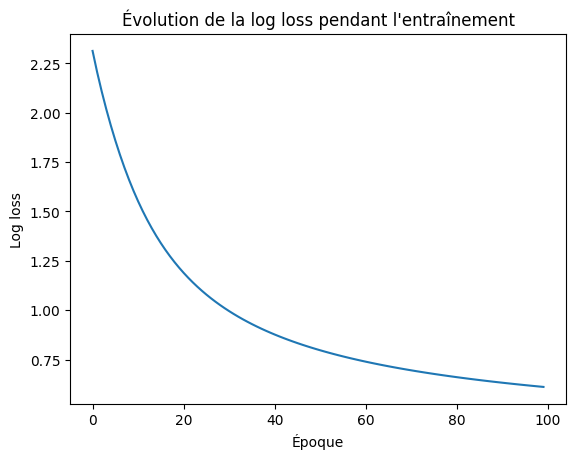

In [60]:
from linear_model import train_linear_model

A, b, loss_history = train_linear_model(
    X_train_flat,
    Y_train,
    input_dim=784,
    num_classes=10,
    learning_rate=0.1,
    epochs=100
)

print("Dernière log loss :", loss_history[-1])

print("Première log loss :", loss_history[0])
print("Dernière log loss :", loss_history[-1])

import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Évolution de la log loss pendant l'entraînement")
plt.show()

# Test sur train

In [61]:
from linear_model import predict, accuracy

y_pred_train = predict(X_train_flat, A, b)
acc_train = accuracy(y_train, y_pred_train)

print("Accuracy train :", acc_train)

Accuracy train : 0.8612333333333333


In [62]:
y_pred_test = predict(X_test_flat, A, b)
acc_test = accuracy(y_test, y_pred_test)

print("Accuracy test :", acc_test)

Accuracy test : 0.8708


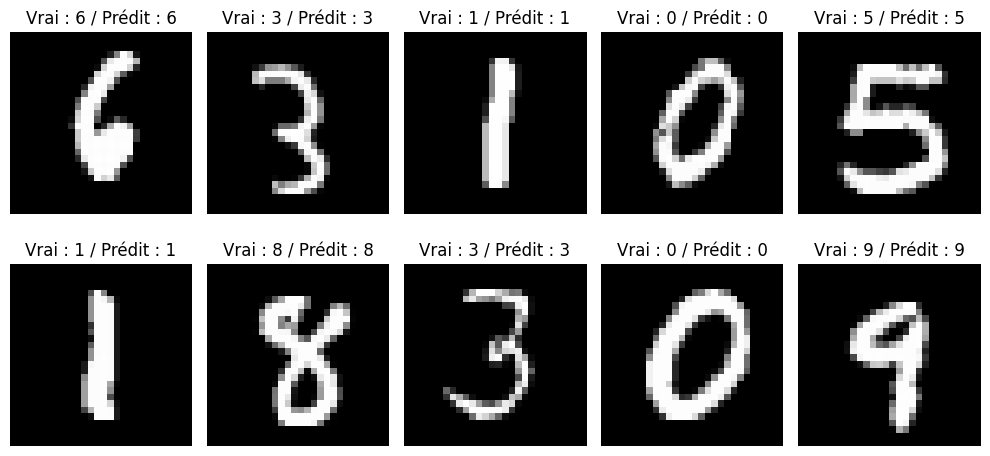

In [63]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
indices = np.random.choice(len(X_test), 10, replace=False)

for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_test[idx], cmap="gray")
    ax.set_title(f"Vrai : {y_test[idx]} / Prédit : {y_pred_test[idx]}")
    ax.axis("off")

plt.tight_layout()
plt.show()